<a href="https://colab.research.google.com/github/jcmachicao/knowledge_engineering/blob/main/U2__NLP_Cognitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# 📘 Introducción a SpaCy con enfoque cognitivo
# Ingeniería del Conocimiento — NLP y Representación Semántica
# ============================================================
* Autor: José Machicao (adaptado para clase)
* Contexto: Uso de SpaCy para explorar cómo el lenguaje refleja estructuras cognitivas y de conocimiento.

# Estructura propuesta del notebook

## Introducción: SpaCy y la cognición lingüística

Qué representa SpaCy en el marco de un sistema cognitivo.

Diferencia entre procesamiento lingüístico y comprensión semántica.

## Configuración del entorno

Instalación de SpaCy y modelo en español (es_core_news_md o es_core_news_lg).

Carga del pipeline y exploración de sus componentes.

## Procesamiento básico

Tokenización, lematización, PoS tagging, dependencias gramaticales.

Explicación de cómo estos pasos reflejan procesos cognitivos como segmentación, clasificación y relaciones jerárquicas del pensamiento.

## Análisis semántico

Extracción de entidades nombradas (NER).

Similitud semántica entre frases.

Ejemplo de “atención conceptual”: medir qué conceptos son más cercanos a un tema dado.

## Construcción de un grafo conceptual simple

Usando relaciones de dependencia o entidades para generar una red semántica (por ejemplo, con networkx).

Reflexión: cómo se puede usar esto para modelar “estructuras de conocimiento” en ingeniería cognitiva.

## Pipeline personalizado

Añadir una regla de detección conceptual (por ejemplo, identificar conceptos de energía o cognición en un texto).

Mostrar cómo extender SpaCy para dominios específicos (Knowledge Engineering, sistemas sociales, etc.)

## Ejercicio cognitivo final

Analizar un párrafo y generar un pequeño resumen semántico: “qué conceptos dominan, qué relaciones emergen y qué implicaciones cognitivas hay”.

# ============================================================
# 1️⃣ Instalación y configuración
# ============================================================

In [ ]:
!pip install -U spacy
!python -m spacy download es_core_news_md

In [2]:
import spacy
from spacy import displacy

In [4]:
# Cargamos el modelo de español (mediano, incluye vectores semánticos)
nlp = spacy.load("es_core_news_md")
print("Modelo cargado:", nlp.meta["name"])

Modelo cargado: core_news_md


In [5]:
# ============================================================
# 2️⃣ Procesamiento básico del lenguaje
# ============================================================

texto = """
La inteligencia artificial está transformando la manera en que las personas
comprenden el conocimiento. Los sistemas cognitivos integran datos,
experiencia y modelos para aprender continuamente.
"""

doc = nlp(texto)

# Tokenización y análisis básico
print("🔹 Tokens, lemas y categorías gramaticales:\n")
for token in doc:
    print(f"{token.text:15} | {token.lemma_:15} | {token.pos_:10} | {token.dep_:10}")

# Reflexión cognitiva:
# - Tokenizar es segmentar el flujo de experiencia en unidades significativas.
# - Lematizar reduce la variabilidad superficial del lenguaje (abstracción conceptual).


🔹 Tokens, lemas y categorías gramaticales:


               | 
               | SPACE      | dep       
La              | el              | DET        | det       
inteligencia    | inteligencia    | NOUN       | nsubj     
artificial      | artificial      | ADJ        | amod      
está            | estar           | AUX        | aux       
transformando   | transformar     | VERB       | ROOT      
la              | el              | DET        | det       
manera          | manera          | NOUN       | obj       
en              | en              | ADP        | case      
que             | que             | SCONJ      | obl       
las             | el              | DET        | det       
personas        | persona         | NOUN       | nsubj     

               | 
               | SPACE      | dep       
comprenden      | comprender      | VERB       | acl       
el              | el              | DET        | det       
conocimiento    | conocimiento    | NOUN       | nsubj  

In [6]:
# ============================================================
# 3️⃣ Dependencias sintácticas (estructura jerárquica del pensamiento)
# ============================================================

# Visualización interactiva de dependencias
displacy.render(doc, style="dep", jupyter=True)

# En este grafo se observa cómo el cerebro o un modelo cognitivo
# puede inferir jerarquías de ideas: sujeto → verbo → objeto.

In [7]:
# ============================================================
# 4️⃣ Extracción de entidades nombradas
# ============================================================

print("\n🔹 Entidades nombradas detectadas:\n")
for ent in doc.ents:
    print(f"{ent.text:30} | {ent.label_}")

# Reflexión cognitiva:
# Las entidades son "nodos de conocimiento".
# Identificar entidades es una forma de mapear los objetos conceptuales
# sobre los cuales se construyen los modelos mentales.


🔹 Entidades nombradas detectadas:

Los sistemas cognitivos integran datos | MISC


In [8]:
# ============================================================
# 5️⃣ Similitud semántica — Juicio conceptual
# ============================================================

frase1 = nlp("La inteligencia artificial puede aprender del entorno.")
frase2 = nlp("Los sistemas cognitivos aprenden de la experiencia.")

similaridad = frase1.similarity(frase2)
print(f"\n🔹 Similitud conceptual entre frases: {similaridad:.3f}")

# Reflexión cognitiva:
# Este cálculo se basa en vectores distribucionales: si dos frases
# aparecen en contextos similares, comparten significado implícito.


🔹 Similitud conceptual entre frases: 0.690


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


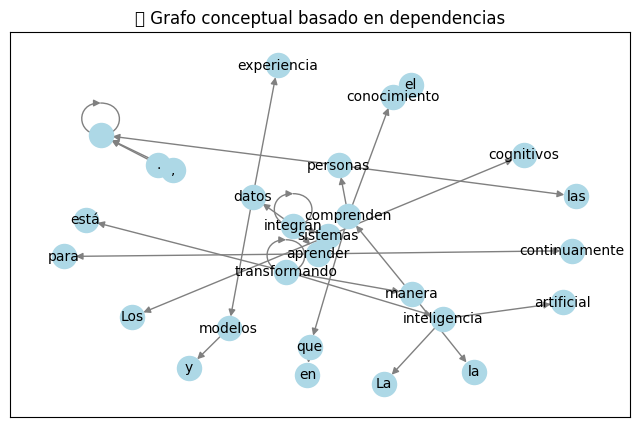

In [9]:
# ============================================================
# 6️⃣ Construcción de un grafo conceptual simple
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for token in doc:
    if token.dep_ != "punct":
        G.add_edge(token.head.text, token.text)

plt.figure(figsize=(8, 5))
nx.draw_networkx(G, with_labels=True, node_color="lightblue", edge_color="gray", font_size=10)
plt.title("🔹 Grafo conceptual basado en dependencias")
plt.show()

# Reflexión cognitiva:
# Este grafo puede interpretarse como una red conceptual: los nodos son ideas
# y las aristas son relaciones cognitivas (acción, cualidad, pertenencia...).


In [10]:
# ============================================================
# 7️⃣ Pipeline personalizado — Detección de conceptos
# ============================================================

from spacy.language import Language

@Language.component("detector_cognitivo")
def detector_cognitivo(doc):
    conceptos_clave = ["inteligencia", "cognitivo", "conocimiento", "aprendizaje"]
    doc._.conceptos_detectados = [tok.text for tok in doc if tok.lemma_ in conceptos_clave]
    return doc

# Registramos la extensión personalizada
from spacy.tokens import Doc
Doc.set_extension("conceptos_detectados", default=[], force=True)

# Añadimos el componente al pipeline
nlp.add_pipe("detector_cognitivo", last=True)

# Procesamos el texto nuevamente
doc = nlp(texto)

print("\n🔹 Conceptos cognitivos detectados:")
print(doc._.conceptos_detectados)

# Reflexión:
# Aquí SpaCy actúa como un "observador cognitivo" que identifica conceptos clave
# en función de una ontología o dominio de interés.



🔹 Conceptos cognitivos detectados:
['inteligencia', 'conocimiento', 'cognitivos']


In [11]:
# ============================================================
# 8️⃣ Ejercicio final — Resumen cognitivo del texto
# ============================================================

from collections import Counter

# Contar sustantivos más frecuentes (representan conceptos dominantes)
sustantivos = [tok.lemma_ for tok in doc if tok.pos_ == "NOUN"]
frecuencias = Counter(sustantivos)

print("🔹 Conceptos dominantes:")
for concepto, freq in frecuencias.most_common(5):
    print(f"{concepto:20} → {freq}")

# Reflexión:
# Un sistema cognitivo podría usar esto para determinar cuáles son las ideas
# más influyentes o centrales en una narrativa.


🔹 Conceptos dominantes:
inteligencia         → 1
manera               → 1
persona              → 1
conocimiento         → 1
sistema              → 1


# ============================================================
# 🧩 Conclusión general
# ============================================================

El procesamiento del lenguaje natural (NLP) en SpaCy permite modelar
procesos cognitivos fundamentales:

- Segmentación (tokenización)  → percepción del mundo.
- Lematización → abstracción de patrones.
- Dependencias → estructura del pensamiento.
- Similitud → juicio conceptual.
- Entidades → nodos de conocimiento.
- Redes conceptuales → representación de experiencia.

En Ingeniería del Conocimiento, estas herramientas permiten
construir sistemas capaces de representar, razonar y aprender
de la información lingüística, un paso clave hacia sistemas cognitivos integrados.

